# 05 - Visualizações para o seminário

Este notebook consolida os artefatos anteriores em figuras com pouco
texto e alta legibilidade. Execute os notebooks 02--04 antes dele.
Cada saída é salva em PNG (slides) e, quando vetorial, também em PDF.

In [1]:
from pathlib import Path


def locate_seminar_dir():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        seminar = candidate if candidate.name == "seminar_2" else candidate / "seminar_2"
        if (seminar / "articles").is_dir():
            return seminar
    raise FileNotFoundError("Execute este notebook dentro do repositório TP558.")


SEMINAR_DIR = locate_seminar_dir()
DATA_DIR = SEMINAR_DIR / "data"
OUTPUT_DIR = DATA_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(SEMINAR_DIR)

/home/matheus/Documentos/mestrado/repositories/matheus-983-tp558/seminar_2


In [2]:
import csv

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyArrowPatch, Rectangle
from PIL import Image

required = [
    OUTPUT_DIR / "paper_data_engine.png",
    OUTPUT_DIR / "paper_image_speed_accuracy.png",
    OUTPUT_DIR / "paper_vos_comparison.png",
    OUTPUT_DIR / "demo_segmentation_strip.png",
]
missing = [path.name for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(f"Execute os notebooks 02--04. Ausentes: {missing}")

## Diagrama da arquitetura

A memória fecha o ciclo entre a máscara prevista e os próximos frames.
O prompt entra diretamente no decoder, permitindo correção iterativa.

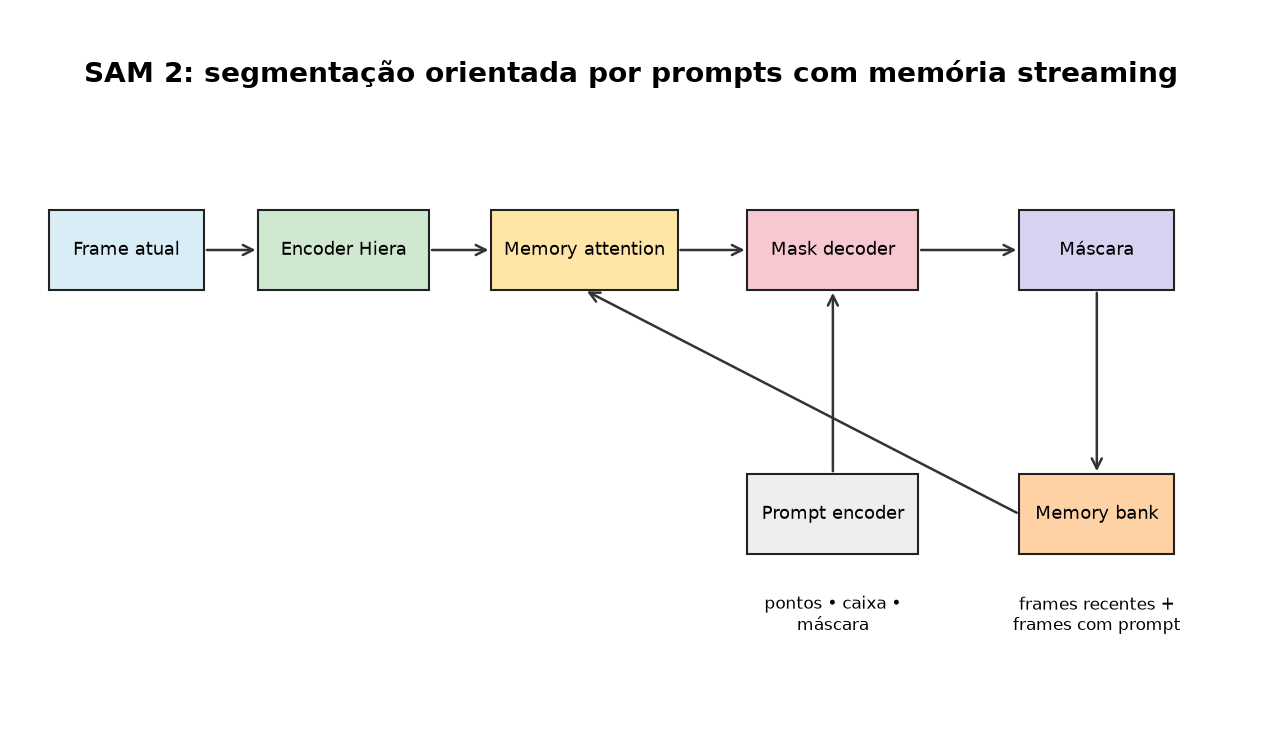

In [3]:
fig, ax = plt.subplots(figsize=(13.33, 7.5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis("off")

blocks = [
    (0.5, 5.5, 2.0, 1.0, "Frame atual", "#d9edf7"),
    (3.2, 5.5, 2.2, 1.0, "Encoder Hiera", "#cfe8cf"),
    (6.2, 5.5, 2.4, 1.0, "Memory attention", "#ffe6a7"),
    (9.5, 5.5, 2.2, 1.0, "Mask decoder", "#f7c8d0"),
    (13.0, 5.5, 2.0, 1.0, "Máscara", "#d8d1f0"),
    (9.5, 2.2, 2.2, 1.0, "Prompt encoder", "#eeeeee"),
    (13.0, 2.2, 2.0, 1.0, "Memory bank", "#ffd2a6"),
]
for x, y, width, height, label, color in blocks:
    ax.add_patch(Rectangle((x, y), width, height, facecolor=color, edgecolor="#222", linewidth=1.5))
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center", fontsize=13)

for start, end in [
    ((2.5, 6), (3.2, 6)), ((5.4, 6), (6.2, 6)), ((8.6, 6), (9.5, 6)),
    ((11.7, 6), (13, 6)), ((10.6, 3.2), (10.6, 5.5)),
    ((14, 5.5), (14, 3.2)), ((13, 2.7), (7.4, 5.5)),
]:
    ax.add_patch(FancyArrowPatch(start, end, arrowstyle="->", mutation_scale=18, color="#333", linewidth=1.8))

ax.text(8, 8.1, "SAM 2: segmentação orientada por prompts com memória streaming", ha="center", fontsize=20, weight="bold")
ax.text(10.6, 1.25, "pontos • caixa •\nmáscara", ha="center", fontsize=12)
ax.text(14, 1.25, "frames recentes +\nframes com prompt", ha="center", fontsize=12)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "slide_architecture.png", dpi=200, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "slide_architecture.pdf", bbox_inches="tight")
plt.show()

## Painel de resultados

O painel junta eficiência de anotação, velocidade/acurácia, benchmark
VOS e a demonstração local. A legenda inferior impede confundir dados
publicados com a execução didática.

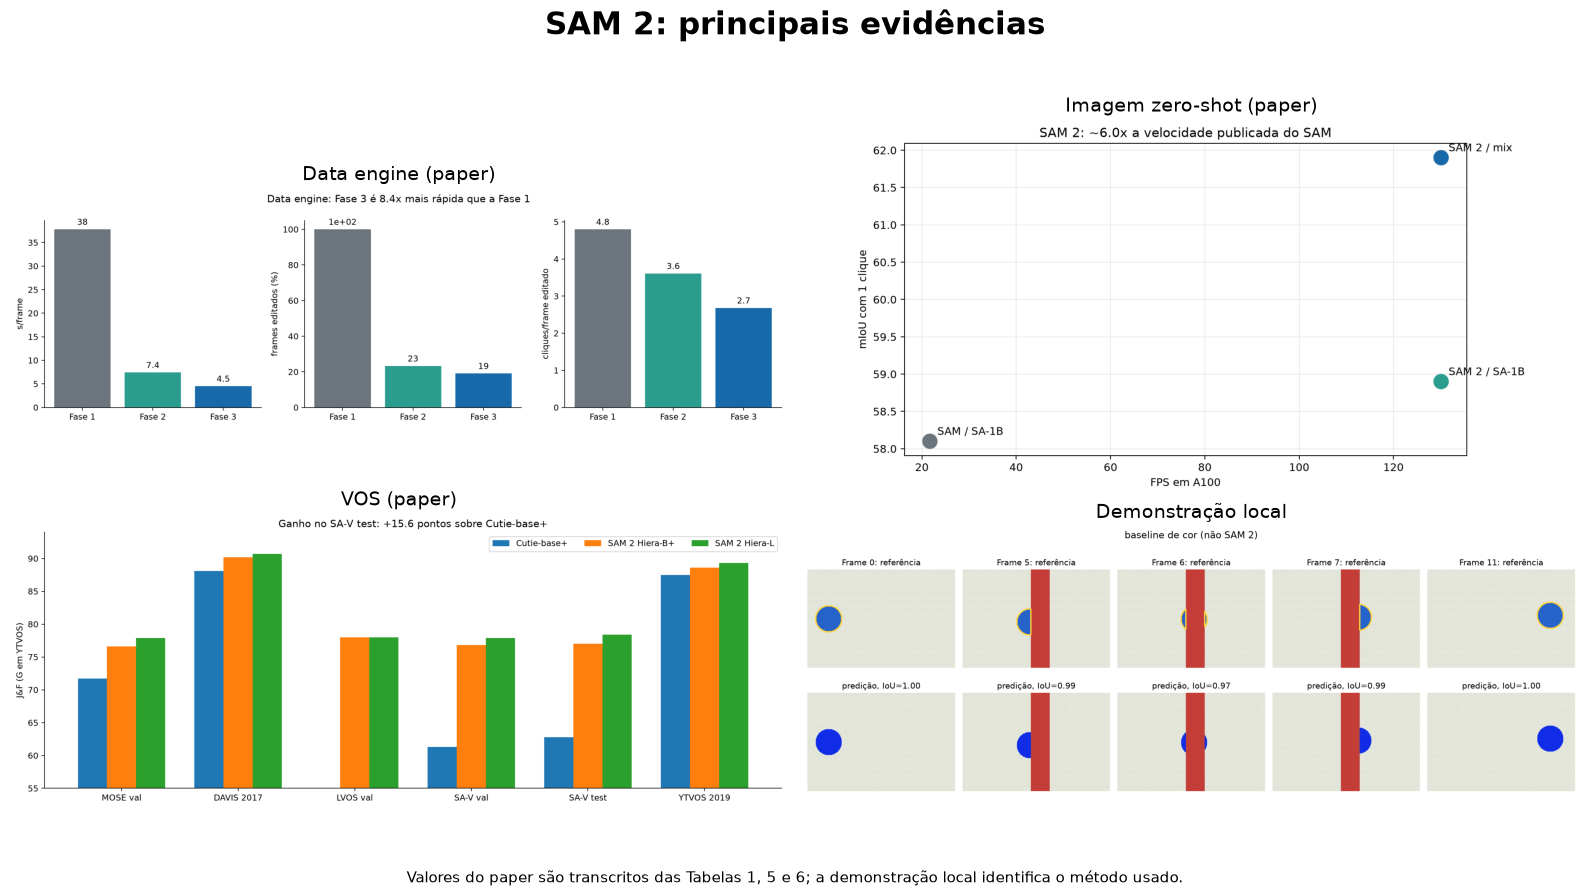

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for ax, path, title in zip(
    axes.flat,
    required,
    ["Data engine (paper)", "Imagem zero-shot (paper)", "VOS (paper)", "Demonstração local"],
    strict=True,
):
    ax.imshow(Image.open(path))
    ax.set_title(title, fontsize=14)
    ax.axis("off")
fig.suptitle("SAM 2: principais evidências", fontsize=22, weight="bold")
fig.text(0.5, 0.01, "Valores do paper são transcritos das Tabelas 1, 5 e 6; a demonstração local identifica o método usado.", ha="center", fontsize=11)
fig.tight_layout(rect=(0, 0.03, 1, 0.95))
fig.savefig(OUTPUT_DIR / "slide_results_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()

## Slide de números-chave

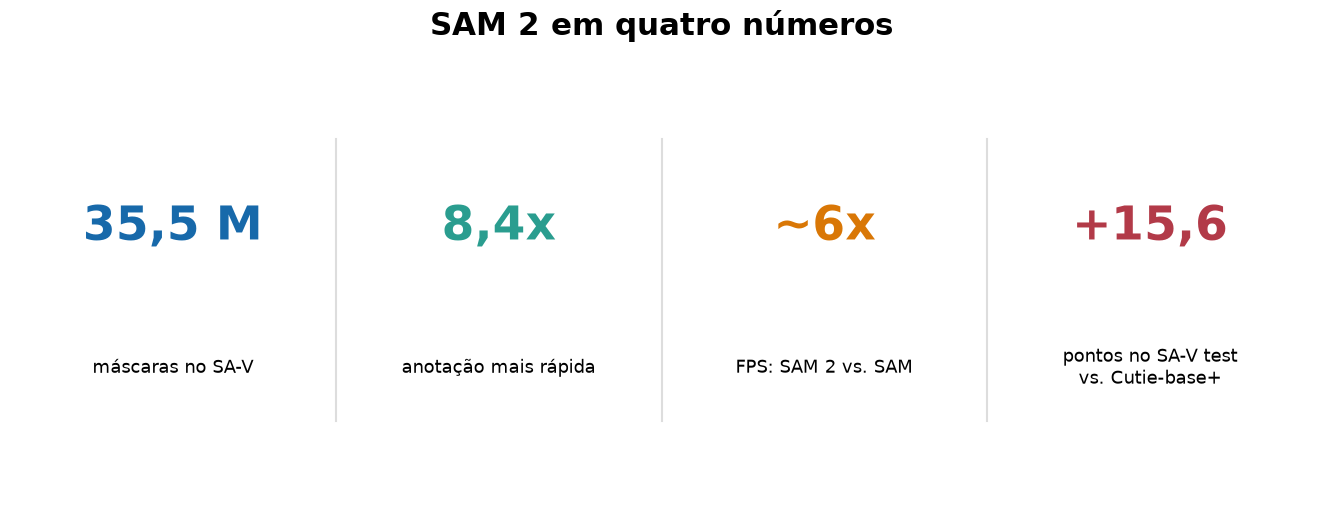

In [5]:
cards = [
    ("35,5 M", "máscaras no SA-V", "#1769aa"),
    ("8,4x", "anotação mais rápida", "#2a9d8f"),
    ("~6x", "FPS: SAM 2 vs. SAM", "#d97706"),
    ("+15,6", "pontos no SA-V test\nvs. Cutie-base+", "#b23a48"),
]
fig, ax = plt.subplots(figsize=(13.33, 5.2))
ax.set_xlim(0, 4)
ax.set_ylim(0, 1)
ax.axis("off")
for index, (number, label, color) in enumerate(cards):
    ax.text(index + 0.5, 0.62, number, ha="center", va="center", fontsize=34, weight="bold", color=color)
    ax.text(index + 0.5, 0.30, label, ha="center", va="center", fontsize=13)
    if index:
        ax.axvline(index, ymin=0.18, ymax=0.82, color="#dddddd")
ax.set_title("SAM 2 em quatro números", fontsize=22, weight="bold", pad=18)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "slide_key_numbers.png", dpi=200, bbox_inches="tight")
fig.savefig(OUTPUT_DIR / "slide_key_numbers.pdf", bbox_inches="tight")
plt.show()

## Inventário das figuras

A célula final lista os caminhos que podem ser inseridos diretamente
na apresentação.

In [6]:
assets = sorted(path for path in OUTPUT_DIR.iterdir() if path.suffix.lower() in {".png", ".pdf", ".gif"})
for path in assets:
    print(path.relative_to(SEMINAR_DIR))
assert {"slide_architecture.png", "slide_results_dashboard.png", "slide_key_numbers.png"} <= {path.name for path in assets}

data/outputs/demo_iou_curve.png
data/outputs/demo_segmentation_strip.png
data/outputs/paper_data_engine.png
data/outputs/paper_image_speed_accuracy.png
data/outputs/paper_prompt_comparison.png
data/outputs/paper_training_phases.png
data/outputs/paper_vos_comparison.png
data/outputs/sam2_architecture_overview.png
data/outputs/slide_architecture.pdf
data/outputs/slide_architecture.png
data/outputs/slide_key_numbers.pdf
data/outputs/slide_key_numbers.png
data/outputs/slide_results_dashboard.png
data/outputs/video_demo.gif
data/outputs/video_demo_contact_sheet.png
data/outputs/video_demo_prompts.png
